In [1]:
!pip install --upgrade pyarrow -q
!pip install mp-api matminer pymatgen xgboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━

In [2]:
from mp_api.client import MPRester
import pandas as pd
from matminer.featurizers.conversions import StrToComposition
from matminer.featurizers.composition import ElementProperty
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score

API_KEY = "T8NM32mVsIRiBobfmd99WiWnIoByjVuX"

with MPRester(API_KEY) as mpr:
    docs = mpr.materials.summary.search(
        band_gap=(0, 6.0), num_chunks=30, chunk_size=1000,
        fields=["material_id", "formula_pretty", "band_gap", "is_metal",
                "density", "volume", "nsites", "energy_above_hull", "formation_energy_per_atom"]
    )

data = [{
    "Material_ID": d.material_id, "Formula": d.formula_pretty, "Bandgap_eV": d.band_gap,
    "Is_Metal": d.is_metal, "Density": d.density, "Volume": d.volume, "Num_Sites": d.nsites,
    "Energy_Above_Hull": d.energy_above_hull, "Formation_Energy": d.formation_energy_per_atom
} for d in docs]

df_large = pd.DataFrame(data)
df_large["Is_Stable"] = df_large["Energy_Above_Hull"] <= 0.05
print(f"Retrieved {len(df_large)} materials")

df_ml_fixed = df_large[["Material_ID", "Formula", "Bandgap_eV", "Is_Metal", "Is_Stable"]].copy()
df_ml_fixed = df_ml_fixed.rename(columns={"Formula": "formula"})
df_ml_fixed = StrToComposition(target_col_id="composition").featurize_dataframe(df_ml_fixed, col_id="formula", ignore_errors=True)
df_ml_fixed = df_ml_fixed.dropna(subset=["composition"])
df_ml_fixed = ElementProperty.from_preset("magpie").featurize_dataframe(df_ml_fixed, col_id="composition", ignore_errors=True)
print(f"Featurized {len(df_ml_fixed)} materials")

df_combined_fixed = df_ml_fixed.merge(
    df_large[["Material_ID", "Density", "Volume", "Num_Sites", "Energy_Above_Hull", "Formation_Energy"]],
    on="Material_ID", how="inner"
)

feature_cols_combined = ["Bandgap_eV", "Density", "Volume", "Num_Sites", "Formation_Energy"] + \
                         [c for c in df_combined_fixed.columns if c.startswith("MagpieData")]

X_combined = df_combined_fixed[feature_cols_combined]
y_combined = df_combined_fixed["Is_Stable"]
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_combined, test_size=0.2, random_state=42, stratify=y_combined)

print("SETUP COMPLETE")

# Save immediately so we never have to redo this slow step again
df_combined_fixed.to_csv('materials_data_30k.csv', index=False)
from google.colab import files
files.download('materials_data_30k.csv')

Retrieving SummaryDoc documents:   0%|          | 0/30000 [00:00<?, ?it/s]

Retrieved 30000 materials


StrToComposition:   0%|          | 0/30000 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/30000 [00:00<?, ?it/s]

Featurized 30000 materials
SETUP COMPLETE


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score

model_xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss')
model_xgb.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "Feature": feature_cols_combined,
    "Importance": model_xgb.feature_importances_
}).sort_values("Importance", ascending=False)

top_features = importance_df.head(60)["Feature"].tolist()

X_selected = df_combined_fixed[top_features]
y_selected = df_combined_fixed["Is_Stable"]

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y_selected, test_size=0.2, random_state=42, stratify=y_selected
)

model_xgb_selected = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=42, eval_metric='logloss'
)

model_xgb_selected.fit(X_train_sel, y_train_sel)
preds_sel = model_xgb_selected.predict(X_test_sel)

acc_sel = accuracy_score(y_test_sel, preds_sel)
f1_sel = f1_score(y_test_sel, preds_sel)
cv_scores_sel = cross_val_score(model_xgb_selected, X_selected, y_selected, cv=5)

print(f"=== XGBOOST — TOP 60 FEATURES ONLY ===")
print(f"Test Accuracy: {acc_sel*100:.1f}%")
print(f"F1 Score: {f1_sel:.3f}")
print(f"Cross-Val Mean: {cv_scores_sel.mean()*100:.1f}% (+/- {cv_scores_sel.std()*100:.2f}%)")

print(f"\n=== FULL JOURNEY ===")
print(f"3k data, RF, all features:     73.2% (+/-3.17%) cross-val")
print(f"30k data, RF, all features:    72.0% (+/-2.98%) cross-val")
print(f"30k data, XGBoost, all 137:    75.7% (+/-4.25%) cross-val")
print(f"30k data, XGBoost, top 60:     {cv_scores_sel.mean()*100:.1f}% (+/-{cv_scores_sel.std()*100:.2f}%) cross-val")

=== XGBOOST — TOP 60 FEATURES ONLY ===
Test Accuracy: 88.2%
F1 Score: 0.885
Cross-Val Mean: 76.3% (+/- 3.81%)

=== FULL JOURNEY ===
3k data, RF, all features:     73.2% (+/-3.17%) cross-val
30k data, RF, all features:    72.0% (+/-2.98%) cross-val
30k data, XGBoost, all 137:    75.7% (+/-4.25%) cross-val
30k data, XGBoost, top 60:     76.3% (+/-3.81%) cross-val


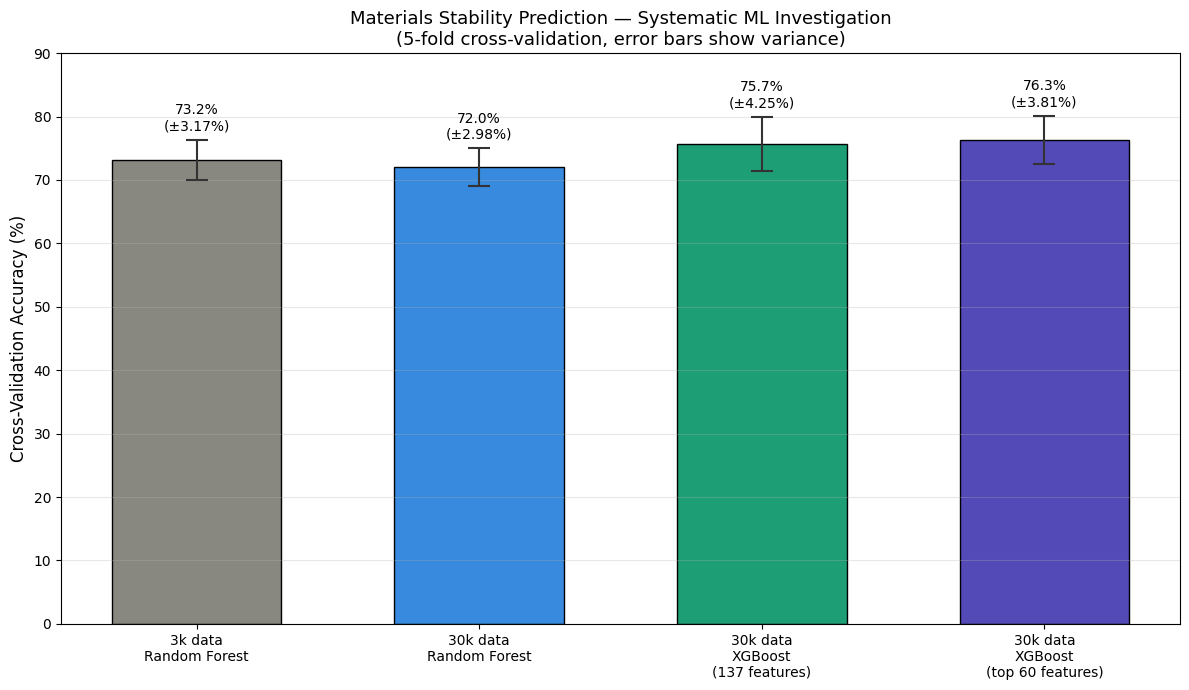

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import matplotlib.pyplot as plt
import numpy as np

experiments = ["3k data\nRandom Forest", "30k data\nRandom Forest",
               "30k data\nXGBoost\n(137 features)", "30k data\nXGBoost\n(top 60 features)"]
accuracy = [73.2, 72.0, 75.7, 76.3]
errors = [3.17, 2.98, 4.25, 3.81]
colors = ["#888780", "#378ADD", "#1D9E75", "#534AB7"]

plt.figure(figsize=(12, 7))
bars = plt.bar(experiments, accuracy, color=colors, edgecolor='black', width=0.6)
plt.errorbar(experiments, accuracy, yerr=errors, fmt='none', ecolor='#333333',
             elinewidth=1.5, capsize=8, capthick=1.5)

for bar, val, err in zip(bars, accuracy, errors):
    plt.text(bar.get_x() + bar.get_width()/2, val + err + 1.5,
              f'{val}%\n(±{err}%)', ha='center', fontsize=10)

plt.ylabel("Cross-Validation Accuracy (%)", fontsize=12)
plt.title("Materials Stability Prediction — Systematic ML Investigation\n(5-fold cross-validation, error bars show variance)", fontsize=13)
plt.ylim(0, 90)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("ml_investigation_journey.png", dpi=150)
plt.show()

from google.colab import files
files.download("ml_investigation_journey.png")